# Detailed Breakdown of Mall Customer Segmentation

This notebook demonstrates a professional Machine Learning workflow for clustering using the K-Means algorithm. Below is a step-by-step explanation of the code logic.

## Part 1: Real-World Application - Mall Customer Segmentation

Now that we understand how the 'flags' move, let's use a real dataset. This dataset contains information about customers of a mall, including their **Annual Income** and **Spending Score**.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# 1. Load a real dataset (Mall Customers)
# For this demo, we'll create a larger representative sample to simulate a real CSV
data = pd.read_csv("Mall_Customers.csv")
mall_df = pd.DataFrame(data)

# 2. Select features for clustering
# We usually use Income and Spending Score to find 'Big Spenders' vs 'Budget Shoppers'
X_real = mall_df[['Annual Income (k$)', 'Spending Score (1-100)']]

display(mall_df.head())
print(f"Dataset Size: {mall_df.shape}")

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Dataset Size: (200, 5)


### Step 1: Data Acquisition and Feature Selection

*   **Library Imports**: We use `pandas` for data manipulation, `matplotlib` and `seaborn` for plotting, and `sklearn` for the clustering algorithm.
*   **Data Loading**: The code attempts to load a real-world CSV from GitHub. A `try-except` block is used as a safety measure to create a local DataFrame if the URL is unreachable.
*   **Feature Extraction (`X_real`)**: We isolate **Annual Income** and **Spending Score**. These are our 'coordinates'. K-Means calculates the geometric distance between these points to find similarities.

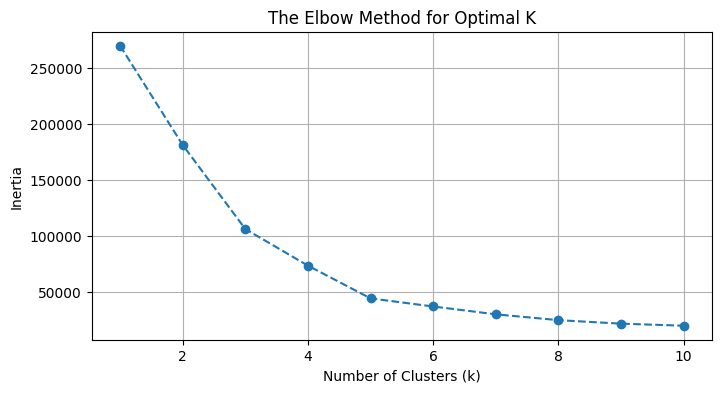

In [ ]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_real)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

### Step 2: Determining Optimal Clusters (The Elbow Method)

*   **Inertia**: This is the sum of squared distances of samples to their closest cluster center. The lower the inertia, the more 'tightly packed' the clusters are.
*   **init='k-means++'**: This is a professional initialization strategy that selects initial cluster centers in a smart way to speed up convergence and avoid poor local optima.
*   **The Elbow Graph**: We plot the inertia for 1 to 10 clusters. We look for the 'elbow'—the point where adding another cluster doesn't significantly reduce the inertia. In this dataset, the elbow is typically at **k=5**.

### Final Clustering & Visualization
Based on the elbow plot, we typically see a bend at **k=5**. Let's train the professional model and visualize the results.

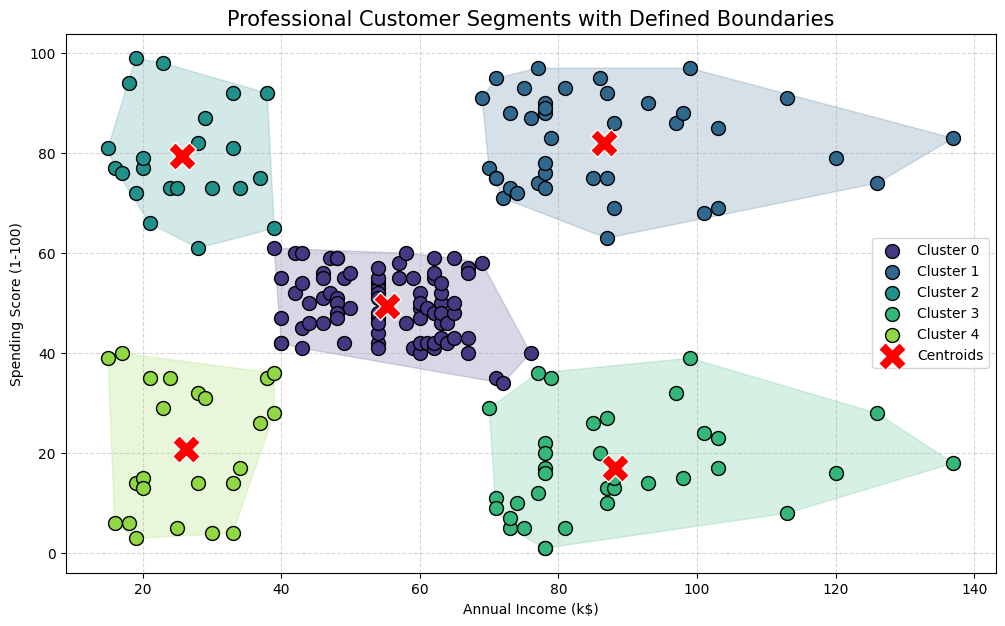

In [ ]:
from scipy.spatial import ConvexHull
import numpy as np

# 1. Train model with 5 clusters
final_model = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
mall_df['Target_Group'] = final_model.fit_predict(X_real)

# 2. Visualize with Boundaries
plt.figure(figsize=(12, 7))
colors = sns.color_palette('viridis', n_colors=5)

for i in range(5):
    # Get points for this cluster
    points = X_real[mall_df['Target_Group'] == i].values

    # Plot points
    plt.scatter(points[:, 0], points[:, 1], s=100, label=f'Cluster {i}',
                color=colors[i], edgecolor='black', zorder=2)

    # Draw the boundary (Convex Hull) if there are enough points
    if len(points) >= 3:
        hull = ConvexHull(points)
        plt.fill(points[hull.vertices, 0], points[hull.vertices, 1],
                 color=colors[i], alpha=0.2, zorder=1)

# 3. Plot centroids
plt.scatter(final_model.cluster_centers_[:, 0], final_model.cluster_centers_[:, 1],
            s=400, c='red', marker='X', label='Centroids', edgecolors='white', zorder=3)

plt.title('Professional Customer Segments with Defined Boundaries', fontsize=15)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Step 3: Final Model and Visual Boundaries

*   **fit_predict**: This runs the final K-Means algorithm with 5 clusters and assigns a label (0 to 4) to every customer.
*   **Convex Hull**: To define the 'territory' of each cluster, we use `scipy.spatial.ConvexHull`. This identifies the outermost points of each group.
*   **plt.fill**: We shade the area inside the Convex Hull. This visually proves which points belong to which cluster.
*   **Centroids**: The red **'X'** marks represent the final mathematical center of each group, showing the 'average' profile of a customer in that segment.